# Time Series Forecasting with LSTM: Air Passengers Dataset

This notebook demonstrates time series forecasting on the classic airline passengers dataset using a PyTorch LSTM model.

## Overview

**Main Steps:**

1. Load monthly airline passenger data from a CSV URL
2. Split the data into training and test sets
3. Convert the time series into supervised learning sequences
4. Define an LSTM-based regression model for sequence prediction
5. Perform a sanity check by overfitting a single batch
6. Train the model on the full dataset and track RMSE for train/test sets
7. Visualize training progress and prediction results

**Motivation:** Based on [LSTM for Time Series Prediction in PyTorch](https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/)


## 1. Imports and Setup


In [ ]:
from auxtorch import (
    count_parameters,
    predict,
    print_model_parameters,
    print_model_structure,
)
from helpers import (
    plot_train_vs_test_error,
    plot_true_vs_pred_scatter,
    plot_true_vs_pred_timeseries,
)


## 2. Configuration Parameters


In [2]:
# Dataset and model configuration
TEST_SIZE_RATIO = 0.3
SEQUENCE_LENGTH = 12
NUM_LSTM_LAYERS = 1
HIDDEN_SIZE = 72
NUM_EPOCHS = 10_000
LEARNING_RATE = 0.001

dataset_url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
)

print(f"Configuration:")
print(f"- Test size ratio: {TEST_SIZE_RATIO}")
print(f"- Sequence length: {SEQUENCE_LENGTH}")
print(f"- LSTM layers: {NUM_LSTM_LAYERS}")
print(f"- Hidden size: {HIDDEN_SIZE}")
print(f"- Number of epochs: {NUM_EPOCHS}")
print(f"- Learning rate: {LEARNING_RATE}")

Configuration:
- Test size ratio: 0.3
- Sequence length: 12
- LSTM layers: 1
- Hidden size: 72
- Number of epochs: 10000
- Learning rate: 0.001


## 3. Utility Functions


In [3]:
def split_train_test(data, test_size_ratio=0.3):
    """Split time series data into train and test sets."""
    train_size = int(len(data) * (1 - test_size_ratio))
    train = data[0:train_size]
    test = data[train_size : len(data)]
    return train, test


def create_sequences(data, seq_length):
    """Convert time series data into sequences for supervised learning."""
    X, y = [], []
    for i in range(data.shape[0] - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])  # Predict the next single value
    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.float32)
    return X, y

## 4. Model Definition


In [4]:
class AirPassengerModel(nn.Module):
    """LSTM-based model for time series forecasting."""

    def __init__(self, input_size=1, hidden_size=50, num_layers=1, batch_first=True):
        super().__init__()
        self.recur = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=batch_first,
        )
        self.ffn = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x, _ = self.recur(x)
        x = self.ffn(x[:, -1, :])  # Use only the last time step
        return x

## 5. Data Loading and Preprocessing


Dataset shape: (144, 1)


<Axes: xlabel='Month'>

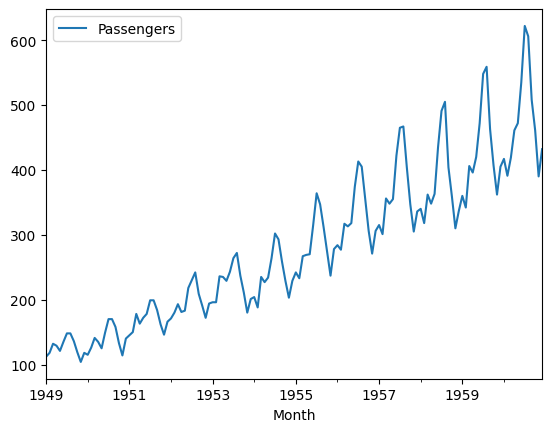

In [ ]:
# Load the dataset
df = pd.read_csv(dataset_url, index_col="Month", parse_dates=True)
print("Dataset shape:", df.shape)
df.plot()

In [6]:
# Convert to numpy array and split into train/test
dv = df.values
train, test = split_train_test(dv, test_size_ratio=TEST_SIZE_RATIO)

print(f"Original data shape: {dv.shape}")
print(f"Training data shape: {train.shape}")
print(f"Test data shape: {test.shape}")

Original data shape: (144, 1)
Training data shape: (100, 1)
Test data shape: (44, 1)


In [7]:
# Create sequences for supervised learning
X_train, y_train = create_sequences(train, seq_length=SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test, seq_length=SEQUENCE_LENGTH)

# Display shapes
shapes = [X_train.shape, y_train.shape, X_test.shape, y_test.shape]
labels = ["X_train", "y_train", "X_test", "y_test"]

print("Sequence shapes:")
for label, shape in zip(labels, shapes):
    print(f"{label}: {shape}")

print(f"\nTotal sequences: {len(X_train) + len(X_test)}")

Sequence shapes:
X_train: torch.Size([88, 12, 1])
y_train: torch.Size([88, 1])
X_test: torch.Size([32, 12, 1])
y_test: torch.Size([32, 1])

Total sequences: 120


In [10]:
# Create data loaders
train_loader = DataLoader(
    dataset=TensorDataset(X_train, y_train), batch_size=16, shuffle=True
)
test_loader = DataLoader(
    dataset=TensorDataset(X_test, y_test), batch_size=16, shuffle=False
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 6
Test batches: 2


## 6. Model Initialization and Inspection


In [11]:
# Initialize the model
model = AirPassengerModel(num_layers=NUM_LSTM_LAYERS, hidden_size=HIDDEN_SIZE)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()

print("Model architecture:")
print(model)

Model architecture:
AirPassengerModel(
  (recur): LSTM(1, 72, batch_first=True)
  (ffn): Linear(in_features=72, out_features=1, bias=True)
)


In [12]:
# Detailed model inspection
print("Model structure:")
print_model_structure(model)

print("\nModel parameters:")
print_model_parameters(model)

print("\nParameter count:")
count_parameters(model)

Model structure:
 -> AirPassengerModel(
  (recur): LSTM(1, 72, batch_first=True)
  (ffn): Linear(in_features=72, out_features=1, bias=True)
)
recur -> LSTM(1, 72, batch_first=True)
ffn -> Linear(in_features=72, out_features=1, bias=True)

Model parameters:
recur.weight_ih_l0             (288, 1) requires_grad=True
recur.weight_hh_l0             (288, 72) requires_grad=True
recur.bias_ih_l0               (288,) requires_grad=True
recur.bias_hh_l0               (288,) requires_grad=True
ffn.weight                     (1, 72) requires_grad=True
ffn.bias                       (1,) requires_grad=True

Parameter count:


21673

## 7. Sanity Check: Overfitting on a Single Batch

Before training on the full dataset, we perform a sanity check by overfitting the model on a single batch. This helps verify that the model can learn from the data.


In [13]:
# Get a single batch for overfitting test
Xb, yb = next(iter(train_loader))
Xb = Xb.clone().detach()
yb = yb.clone().detach()

print(f"Batch shapes - X: {Xb.shape}, y: {yb.shape}")
print(f"Target values: {yb.squeeze()[:5].tolist()}...")  # Show first 5 values

Batch shapes - X: torch.Size([16, 12, 1]), y: torch.Size([16, 1])
Target values: [115.0, 264.0, 277.0, 194.0, 405.0]...


In [14]:
# Overfitting on single batch
train_error = []

for epoch in range(NUM_EPOCHS):
    model.train()
    y_pred = model(Xb)
    loss = loss_fn(y_pred, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 != 0:
        continue

    y_pred_train = predict(model, Xb, return_numpy=False)
    assert y_pred_train.shape == yb.shape
    train_rmse = np.sqrt(loss_fn(y_pred_train, yb).item())
    train_error.append(train_rmse)

    if epoch % 1000 == 0:  # Print every 1000 epochs
        print(f"epoch: {epoch+1}/{NUM_EPOCHS}, train_rmse: {train_rmse:.4f}")

print(f"\nFinal RMSE after overfitting: {train_rmse:.4f}")

epoch: 1/10000, train_rmse: 245.7852
epoch: 1001/10000, train_rmse: 184.1522
epoch: 2001/10000, train_rmse: 138.3064
epoch: 3001/10000, train_rmse: 103.3609
epoch: 4001/10000, train_rmse: 72.9032
epoch: 5001/10000, train_rmse: 52.0857
epoch: 6001/10000, train_rmse: 38.3655
epoch: 7001/10000, train_rmse: 28.9542
epoch: 8001/10000, train_rmse: 21.0387
epoch: 9001/10000, train_rmse: 14.9092

Final RMSE after overfitting: 8.7672


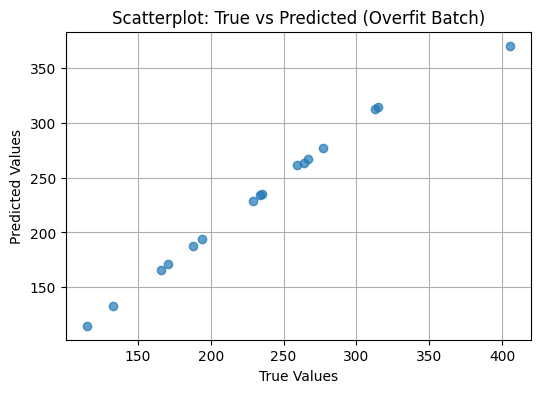

In [15]:
# Visualize overfitting results
plot_true_vs_pred_scatter(
    yb, y_pred_train, title="Scatterplot: True vs Predicted (Overfit Batch)"
)

## 8. Full Dataset Training

Now we train the model on the complete dataset and track both training and test performance.


In [16]:
# Re-initialize model for full training
model = AirPassengerModel()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()
train_error = []
test_error = []

print("Starting full dataset training...")

Starting full dataset training...


In [17]:
# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()
    for Xb, yb in train_loader:
        y_pred = model(Xb)
        loss = loss_fn(y_pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 1 != 0:
        continue

    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train)
        assert y_pred_train.shape == y_train.shape
        train_rmse = np.sqrt(loss_fn(y_pred_train, y_train).item())

        y_pred_test = model(X_test)
        assert y_pred_test.shape == y_test.shape
        test_rmse = np.sqrt(loss_fn(y_pred_test, y_test).item())

    train_error.append(train_rmse)
    test_error.append(test_rmse)

    if epoch % 1000 == 0:  # Print every 1000 epochs
        print(
            f"epoch: {epoch+1}/{NUM_EPOCHS}, train_rmse: {train_rmse:.4f}, test_rmse: {test_rmse:.4f}"
        )

print(f"\nFinal - Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")

epoch: 1/10000, train_rmse: 240.7274, test_rmse: 445.4077
epoch: 1001/10000, train_rmse: 67.1512, test_rmse: 243.3475
epoch: 2001/10000, train_rmse: 16.6826, test_rmse: 131.1198
epoch: 3001/10000, train_rmse: 6.2462, test_rmse: 107.5462
epoch: 4001/10000, train_rmse: 3.1878, test_rmse: 111.1785
epoch: 5001/10000, train_rmse: 3.5587, test_rmse: 109.1594
epoch: 6001/10000, train_rmse: 1.0021, test_rmse: 107.2776
epoch: 7001/10000, train_rmse: 2.2860, test_rmse: 105.8200
epoch: 8001/10000, train_rmse: 0.7068, test_rmse: 106.2437
epoch: 9001/10000, train_rmse: 1.3738, test_rmse: 109.1556

Final - Train RMSE: 3.7167, Test RMSE: 107.3079


## 9. Training Progress Visualization


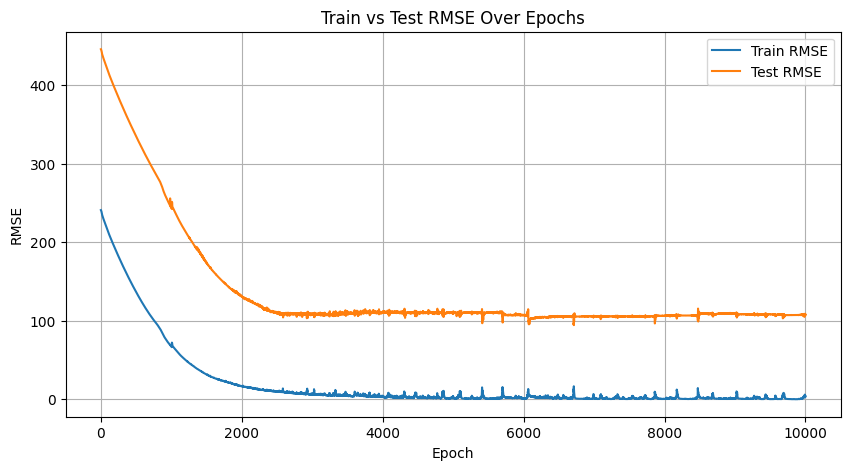

In [18]:
# Plot training and test error over epochs
plot_train_vs_test_error(train_error, test_error)

## 10. Final Evaluation and Predictions


In [19]:
# Evaluate on test batches and collect predictions
y_true, y_pred = [], []

for Xb, yb in test_loader:
    yp = predict(model, Xb, return_numpy=False)
    loss = loss_fn(yp, yb)
    print(f"test batch rmse: {np.sqrt(loss.item()):.4f}")
    y_pred.append(yp)
    y_true.append(yb)

test batch rmse: 93.4728
test batch rmse: 119.5525


In [20]:
# Concatenate all batches for plotting
y_true_all = torch.cat(y_true).cpu().numpy()
y_pred_all = torch.cat(y_pred).cpu().numpy()

print(f"Final evaluation shapes:")
print(f"True values: {y_true_all.shape}")
print(f"Predicted values: {y_pred_all.shape}")

Final evaluation shapes:
True values: (32, 1)
Predicted values: (32, 1)


## 11. Results Visualization


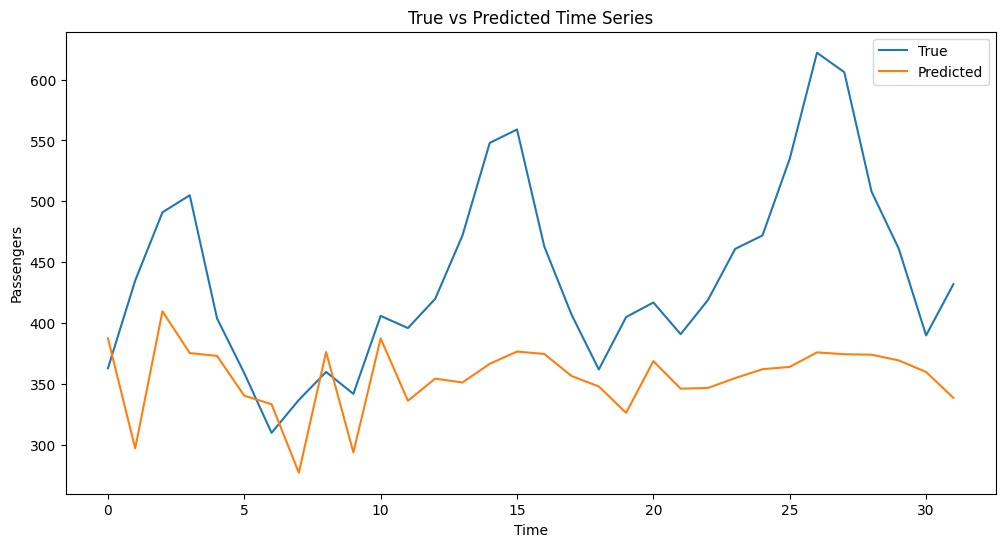

In [21]:
# Plot time series comparison
plot_true_vs_pred_timeseries(y_true_all, y_pred_all)

## Summary

This notebook demonstrated:

1. **Data Preparation**: Loading and preprocessing the airline passengers time series data
2. **Sequence Creation**: Converting time series into supervised learning sequences
3. **Model Architecture**: Implementing an LSTM-based neural network for forecasting
4. **Sanity Check**: Verifying model capability through single-batch overfitting
5. **Training**: Full dataset training with performance monitoring
6. **Evaluation**: Comprehensive evaluation and visualization of results

The LSTM model successfully learned to forecast airline passenger numbers, demonstrating the effectiveness of recurrent neural networks for time series prediction tasks.
